# Importation des librairies

In [1]:
pip install tensorflow

In [2]:
import os
import random

import numpy as np

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Graines

In [3]:
seed = 42

os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Chargement des données

In [4]:
X_train, y_train = tfds.as_numpy(tfds.load(
    'rock_paper_scissors',
    split='train',
    batch_size=-1,
    as_supervised=True,
))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/2520 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/3.0.0.incompleteHBRPOI/rock_paper_scissors-train.tfrec…

Generating test examples...:   0%|          | 0/372 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/3.0.0.incompleteHBRPOI/rock_paper_scissors-test.tfreco…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.


In [5]:
X_test, y_test = tfds.as_numpy(tfds.load(
    'rock_paper_scissors',
    split='test',
    batch_size=-1,
    as_supervised=True,
))

# Pré-traitement des données

In [6]:
feature_vector_length = X_train.shape[1]*X_train.shape[2]*X_train.shape[3]
num_classes = 3

In [7]:
X_train = np.reshape(X_train, (X_train.shape[0], feature_vector_length))

In [8]:
X_test = np.reshape(X_test, (X_test.shape[0], feature_vector_length))

In [9]:
one_hot_encoded_y_train = to_categorical(y_train, num_classes)

In [10]:
one_hot_encoded_y_test = to_categorical(y_test, num_classes)

# Création du modèle

In [11]:
# Set the input shape
input_shape = (feature_vector_length,)
print(f'Feature shape: {input_shape}')

# Create the model
model = Sequential()

model.add(Dense(1024, input_shape=input_shape, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

Feature shape: (270000,)


# Compilation du modèle

In [12]:
# Configure the model
opt = Adam(learning_rate=0.001)

model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# Entrainement du modèle

In [13]:
# Start training
history = model.fit(X_train, one_hot_encoded_y_train, epochs=50, batch_size=32, verbose=1, validation_split=0.2)

Epoch 1/50
63/63 [==============================] - 9s 63ms/step - loss: 50623.3398 - accuracy: 0.4067 - val_loss: 2412.6392 - val_accuracy: 0.5456
Epoch 2/50
63/63 [==============================] - 4s 58ms/step - loss: 1344.6730 - accuracy: 0.7068 - val_loss: 234.2344 - val_accuracy: 0.8889
Epoch 3/50
63/63 [==============================] - 3s 55ms/step - loss: 495.4076 - accuracy: 0.7937 - val_loss: 830.0619 - val_accuracy: 0.7302
Epoch 4/50
63/63 [==============================] - 4s 58ms/step - loss: 488.2163 - accuracy: 0.8125 - val_loss: 88.4362 - val_accuracy: 0.9385
Epoch 5/50
63/63 [==============================] - 4s 59ms/step - loss: 491.2669 - accuracy: 0.8254 - val_loss: 226.4858 - val_accuracy: 0.8690
Epoch 6/50
63/63 [==============================] - 4s 59ms/step - loss: 1045.4039 - accuracy: 0.7351 - val_loss: 303.8127 - val_accuracy: 0.8353
Epoch 7/50
63/63 [==============================] - 3s 55ms/step - loss: 257.7675 - accuracy: 0.8864 - val_loss: 130.2668 - va

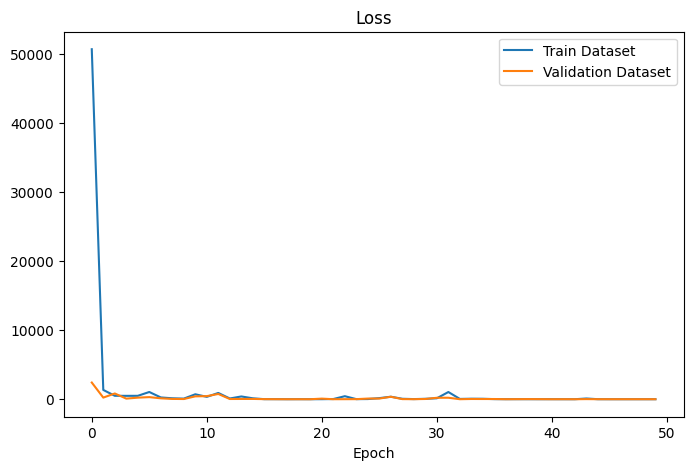

In [14]:
plt.figure(figsize=(8, 5), dpi=100)
plt.title("Loss")
plt.plot(history.history['loss'], label="Train Dataset")
plt.plot(history.history['val_loss'], label="Validation Dataset")
plt.xlabel("Epoch")
plt.legend()
plt.show()

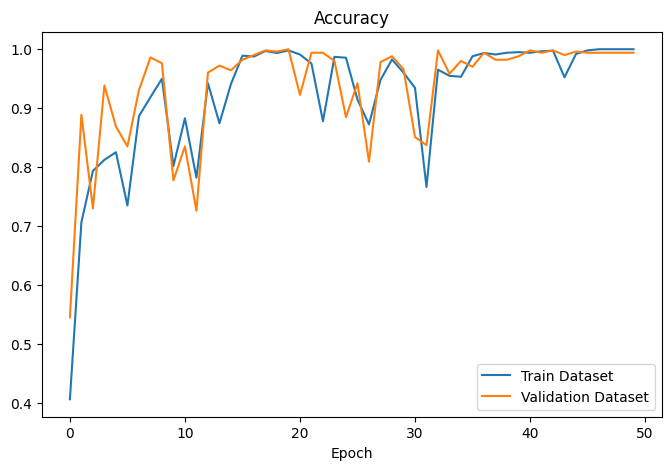

In [15]:
plt.figure(figsize=(8, 5), dpi=100)
plt.title("Accuracy")
plt.plot(history.history['accuracy'], label="Train Dataset")
plt.plot(history.history['val_accuracy'], label="Validation Dataset")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# Performances du modèle sur le jeu d'apprentissage

## Taux de classification

In [16]:
model.evaluate(X_train, one_hot_encoded_y_train)

79/79 [==============================] - 4s 55ms/step - loss: 0.4471 - accuracy: 0.9988


[0.44709545373916626, 0.9988095164299011]

## Matrice de confusion

In [17]:
y_predict_train = np.argmax(model.predict(X_train), axis=-1)

79/79 [==============================] - 5s 59ms/step


In [18]:
cm = confusion_matrix(y_train, y_predict_train, normalize='true')

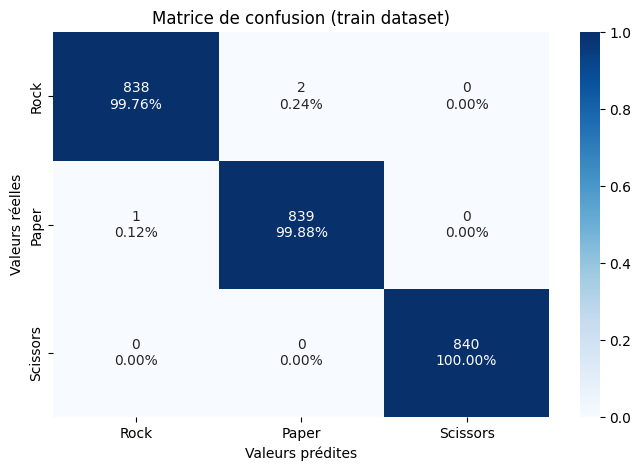

In [19]:
counts = ["{0:0.0f}\n".format(value) for value in confusion_matrix(y_train, y_predict_train, normalize=None).flatten()]
percentages = ["{0:.2%}".format(value) for value in confusion_matrix(y_train, y_predict_train, normalize='true').flatten()]

box_labels = [f"{v1}{v2}" for v1, v2 in zip(counts, percentages)]
box_labels = np.asarray(box_labels).reshape(cm.shape[0],cm.shape[1])

plt.figure(figsize=(8,5), dpi=100)

plt.title("Matrice de confusion (train dataset)")

sns.heatmap(cm,
            vmin=0.0,
            vmax=1.0,
            cmap='Blues',
            annot=box_labels,
            fmt='',
            xticklabels=["Rock", "Paper", "Scissors"],
            yticklabels=["Rock", "Paper", "Scissors"])

plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")

plt.show()

# Performances du modèle sur le jeu de test

## Taux de classification

In [28]:
model.evaluate(X_test, one_hot_encoded_y_test)

12/12 [==============================] - 0s 28ms/step - loss: 2457.6965 - accuracy: 0.5887


[2457.696533203125, 0.5887096524238586]

## Matrice de confusion

In [21]:
y_predict_test = np.argmax(model.predict(X_test), axis=-1)

12/12 [==============================] - 0s 8ms/step


In [22]:
cm = confusion_matrix(y_test, y_predict_test, normalize='true')

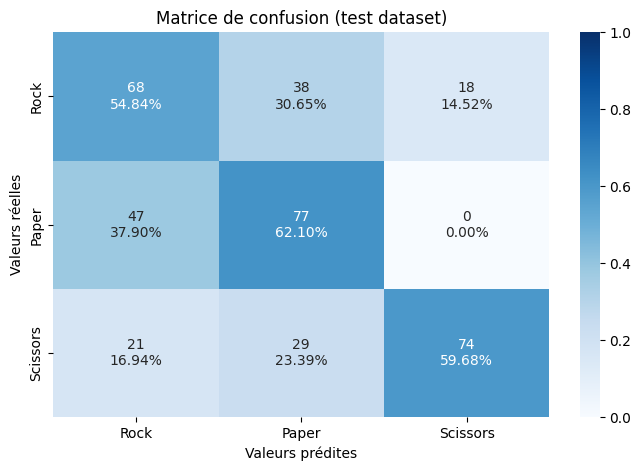

In [23]:
counts = ["{0:0.0f}\n".format(value) for value in confusion_matrix(y_test, y_predict_test, normalize=None).flatten()]
percentages = ["{0:.2%}".format(value) for value in confusion_matrix(y_test, y_predict_test, normalize='true').flatten()]

box_labels = [f"{v1}{v2}" for v1, v2 in zip(counts, percentages)]
box_labels = np.asarray(box_labels).reshape(cm.shape[0],cm.shape[1])

plt.figure(figsize=(8,5), dpi=100)

plt.title("Matrice de confusion (test dataset)")

sns.heatmap(cm,
            vmin=0.0,
            vmax=1.0,
            cmap='Blues',
            annot=box_labels,
            fmt='',
            xticklabels=["Rock", "Paper", "Scissors"],
            yticklabels=["Rock", "Paper", "Scissors"])

plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")

plt.show()